# Benchmark test-structure check

Draws each abl1 mock-up ground truth and the exact task prompt every agent receives (identical across arms). Run top to bottom in the `chemistree` env.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "benchmarks").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

In [2]:
import json

from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw

from benchmarks import run
from benchmarks.tasks import strip_murcko


def load(name):
    p = REPO / "benchmarks" / "cases" / name
    return [json.loads(x) for x in p.read_text().splitlines() if x.strip()]


def grid(smis, legends, size=(340, 260)):
    mols = [Chem.MolFromSmiles(s) if isinstance(s, str) else s for s in smis]
    return Draw.MolsToGridImage(
        mols, legends=legends, molsPerRow=len(mols), subImgSize=size
    )

[substitution] sub-halogen
INSTRUCTION: Replace fluorine with chlorine.

TASK PROMPT (identical across arms):
Replace fluorine with chlorine.
The molecule as SMILES: Cc1cc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)ccc1F
End your reply with a line exactly of the form:
FINAL_SMILES: <smiles>


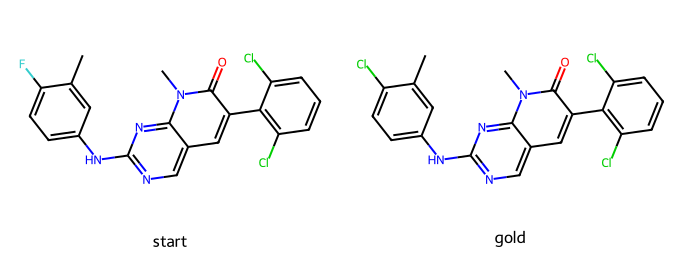

[substitution] sub-ring-to-pyridine
INSTRUCTION: Make the aniline ring a pyridine with N at the carbon para to the Me. Keep all of the substituents.

TASK PROMPT (identical across arms):
Make the aniline ring a pyridine with N at the carbon para to the Me. Keep all of the substituents.
The molecule as SMILES: Cc1cc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)ccc1F
End your reply with a line exactly of the form:
FINAL_SMILES: <smiles>


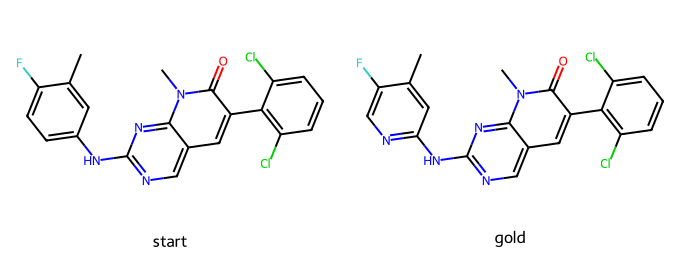

[substitution] swap-to-oxazole
INSTRUCTION: Replace the fluoro phenyl group with a 1,3-oxazole, attaching it at the 2-position and keeping both substituents. Put the methyl at the 5-position and the F at the 4-position.

TASK PROMPT (identical across arms):
Replace the fluoro phenyl group with a 1,3-oxazole, attaching it at the 2-position and keeping both substituents. Put the methyl at the 5-position and the F at the 4-position.
The molecule as SMILES: Cc1cc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)ccc1F
End your reply with a line exactly of the form:
FINAL_SMILES: <smiles>


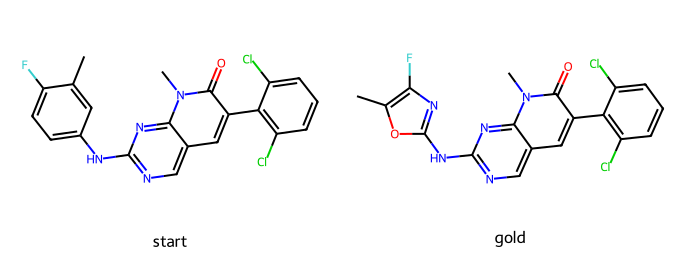

[growing] grow-halogen
INSTRUCTION: Add a Cl ortho to the fluorine.

TASK PROMPT (identical across arms):
Add a Cl ortho to the fluorine.
The molecule as SMILES: Cc1cc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)ccc1F
End your reply with a line exactly of the form:
FINAL_SMILES: <smiles>


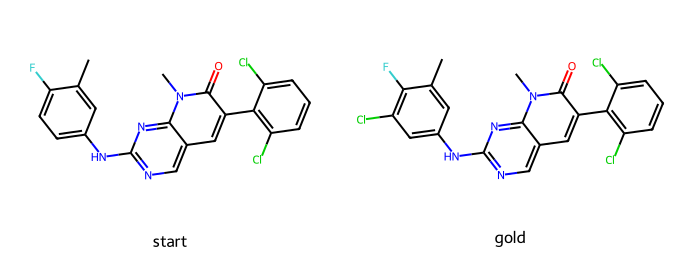

[core_hopping] core-hop-quinazoline
INSTRUCTION: Replace the pyrido-pyrimidinone core with a quinazoline, keeping the aniline group at the 2-position and the 2,6-dichlorophenyl at the 6-position, but dropping the Me.

TASK PROMPT (identical across arms):
Replace the pyrido-pyrimidinone core with a quinazoline, keeping the aniline group at the 2-position and the 2,6-dichlorophenyl at the 6-position, but dropping the Me.
The molecule as SMILES: Cc1cc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)ccc1F
End your reply with a line exactly of the form:
FINAL_SMILES: <smiles>


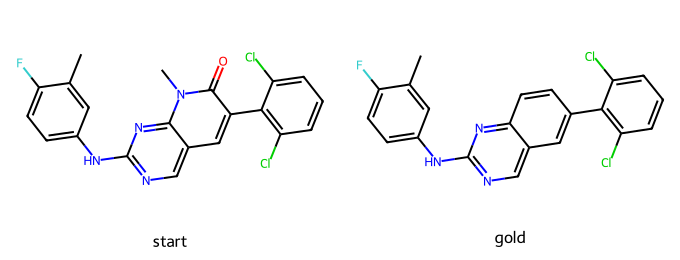

In [3]:
# Track A -- 2D editing: starting molecule -> gold product + the identical task prompt.
for item in load("abl1_2d.jsonl"):
    print("=" * 100)
    print(f"[{item['category']}] {item['id']}")
    print("INSTRUCTION:", item["instruction"])
    print("\nTASK PROMPT (identical across arms):")
    print(run.build_prompt(item, item["smiles"]))
    display(grid([item["smiles"], item["gold"]], ["start", "gold"]))

[decoration] abl1
INSTRUCTION: Optimize the ligand to improve predicted binding.

TASK PROMPT (identical across arms):
A chemical scaffold is posed in a protein binding pocket. Optimize the ligand to improve predicted binding.
The scaffold as SMILES: O=c1[nH]c2nc(Nc3ccccc3)ncc2cc1-c1ccccc1
End your reply with a line exactly of the form:
FINAL_SMILES: <smiles>


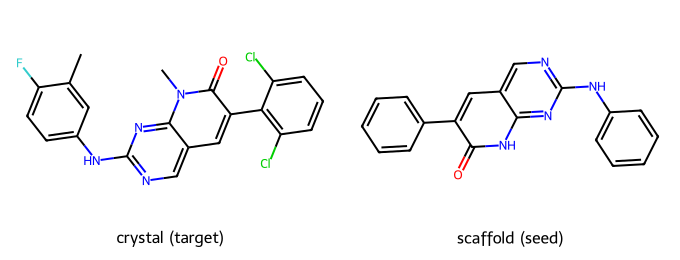

In [4]:
# Track B1 -- scaffold decoration: crystal ligand (target) + Murcko scaffold (seed).
for item in load("abl1_3d_decoration.jsonl"):
    crystal = Chem.MolToSmiles(Chem.MolFromMolFile(str(REPO / item["target"])))
    scaffold = Chem.MolToSmiles(strip_murcko.scaffold_pose(str(REPO / item["target"])))
    print("=" * 100)
    print(f"[decoration] {item['id']}")
    print("INSTRUCTION:", item["instruction"])
    print("\nTASK PROMPT (identical across arms):")
    print(run.build_prompt(item, scaffold))
    display(grid([crystal, scaffold], ["crystal (target)", "scaffold (seed)"]))

[probe] nearest-residue-cl
QUESTION: Which receptor residue (give its residue name and number, e.g. ASP381) has an atom closest to the ligand's chlorine atoms?
GROUND-TRUTH ANSWER: ASP149

TASK PROMPT (identical across arms):
A ligand is posed in a protein binding pocket. Which receptor residue (give its residue name and number, e.g. ASP381) has an atom closest to the ligand's chlorine atoms?
The ligand as SMILES: Cc1cc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)ccc1F
End your reply with a line exactly of the form:
FINAL_ANSWER: <answer>


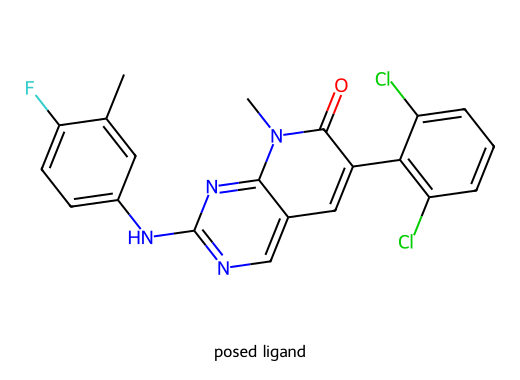

[probe] cl-contact-count
QUESTION: How many receptor residues does the ligand's dichlorophenyl contact through its chlorines - that is, have any atom within 4.0 Angstrom of either chlorine?
GROUND-TRUTH ANSWER: 9

TASK PROMPT (identical across arms):
A ligand is posed in a protein binding pocket. How many receptor residues does the ligand's dichlorophenyl contact through its chlorines - that is, have any atom within 4.0 Angstrom of either chlorine?
The ligand as SMILES: Cc1cc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)ccc1F
End your reply with a line exactly of the form:
FINAL_ANSWER: <answer>


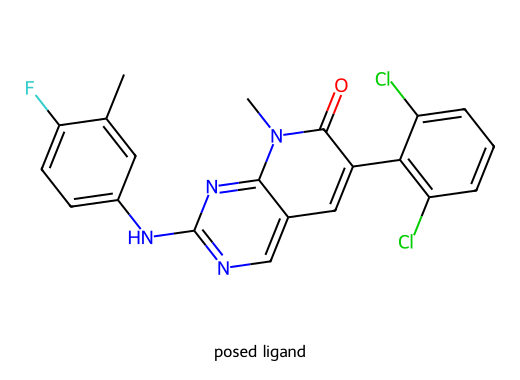

In [5]:
# Track B2 -- understanding probes: posed ligand + question + ground-truth answer.
for item in load("abl1_3d_probes.jsonl"):
    lig = Chem.MolToSmiles(Chem.MolFromMolFile(str(REPO / item["ligand"])))
    print("=" * 100)
    print(f"[probe] {item['id']}")
    print("QUESTION:", item["question"])
    print("GROUND-TRUTH ANSWER:", item["answer"])
    print("\nTASK PROMPT (identical across arms):")
    print(run.build_prompt(item, lig))
    display(grid([lig], ["posed ligand"], size=(520, 380)))